===== ORIGINAL COLUMNS =====
Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

===== CLEANED COLUMNS =====
Index(['number_of_customers_per_day', 'average_order_value',
       'operating_hours_per_day', 'number_of_employees',
       'marketing_spend_per_day', 'location_foot_traffic', 'daily_revenue'],
      dtype='object')

Dependent Variable: daily_revenue
Predictor Variables: ['number_of_customers_per_day', 'average_order_value', 'operating_hours_per_day', 'number_of_employees', 'marketing_spend_per_day', 'location_foot_traffic']

===== SCATTER PLOTS =====


C:\Users\Subhi Jain\AppData\Local\Temp\ipykernel_30192\2058648669.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


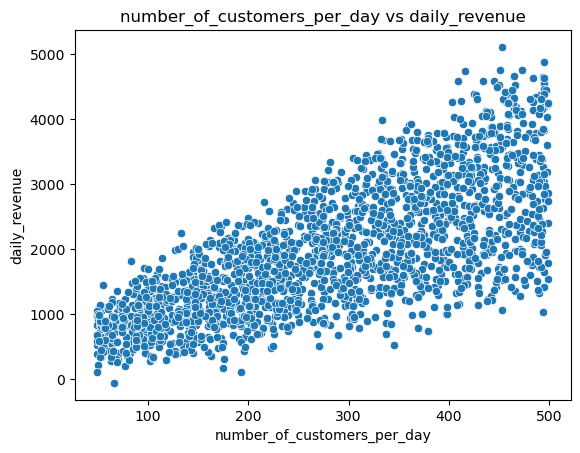

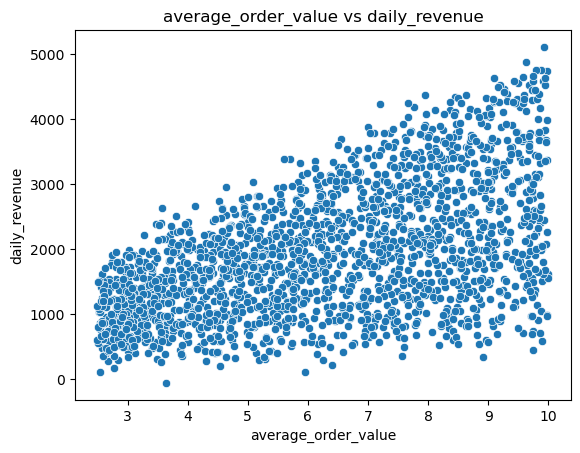

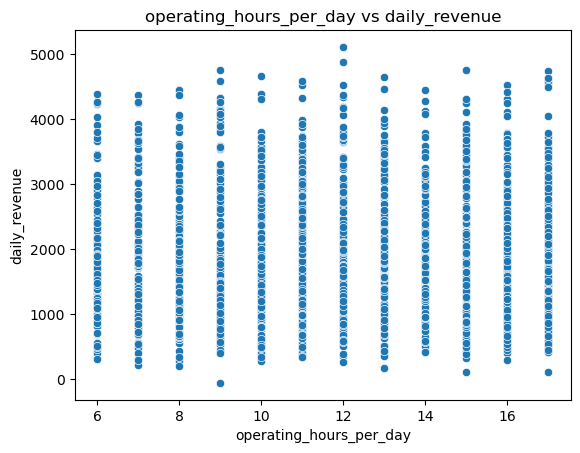

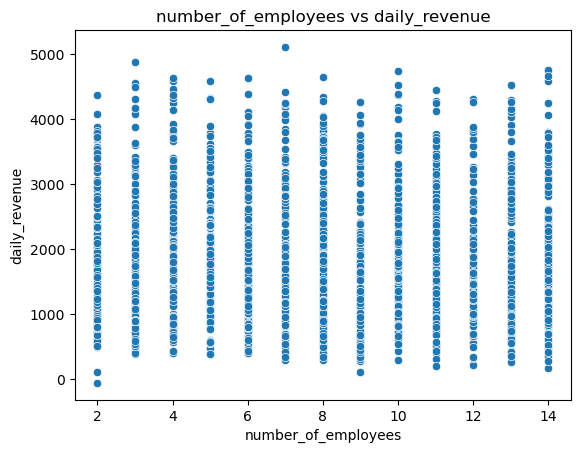

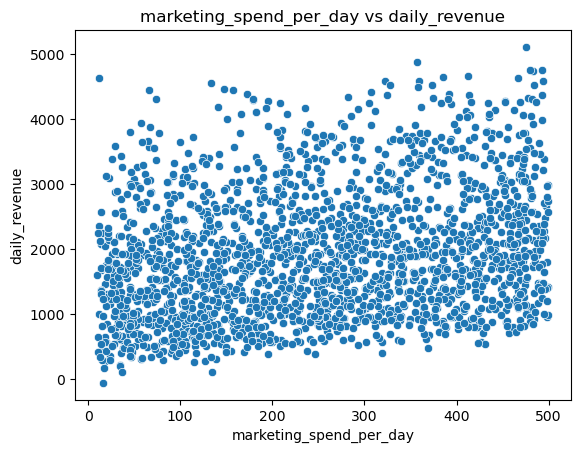

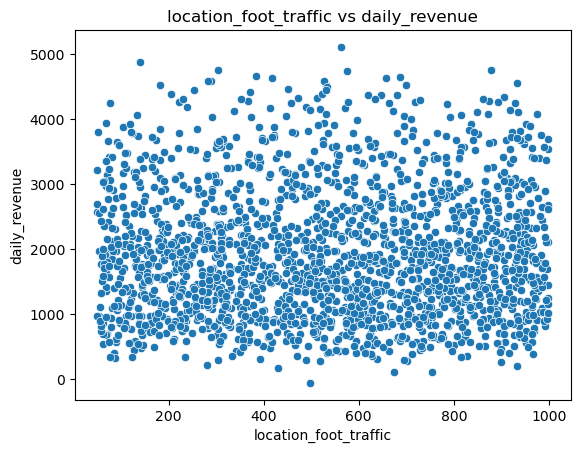


===== SIMPLE LINEAR REGRESSION =====

Feature: number_of_customers_per_day
MSE: 401391.88402129925
R2 Score: 0.570413778585338

Feature: average_order_value
MSE: 678598.8131978735
R2 Score: 0.2737354400452211

Feature: operating_hours_per_day
MSE: 937296.5800141033
R2 Score: -0.0031336262189547437

Feature: number_of_employees
MSE: 936298.5289695181
R2 Score: -0.0020654706480773832

Feature: marketing_spend_per_day
MSE: 870604.9771006439
R2 Score: 0.06824248983166226

Feature: location_foot_traffic
MSE: 938385.140880216
R2 Score: -0.004298649150082268

Best Feature: number_of_customers_per_day


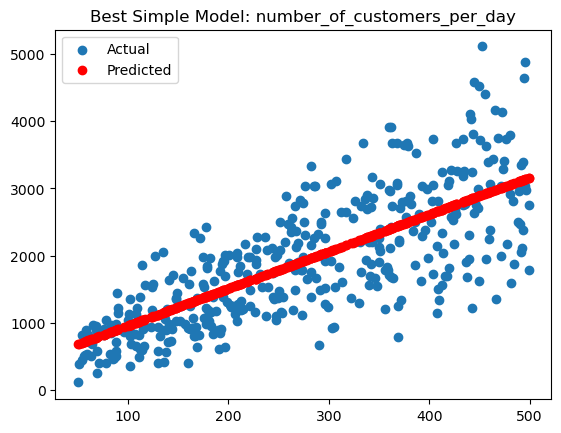


===== MULTIPLE LINEAR REGRESSION =====
MSE (Multiple): 97569.72294013834
R2 Score (Multiple): 0.8955768408109982

===== COMPARISON =====
Best Simple MSE: 401391.88402129925
Multiple Regression MSE: 97569.72294013834
Multiple Linear Regression performs better.


In [3]:
# =========================================================
# LINEAR REGRESSION - coffee_shop_revenue dataset
# FULL ERROR-FREE VERSION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# STEP 1: LOAD DATASET
# ---------------------------------------------------------
df = pd.read_csv(r"C:\Users\Subhi Jain\Desktop\dsbda-prac_227\datasets\coffee_shop_revenue.csv")

print("===== ORIGINAL COLUMNS =====")
print(df.columns)

# ---------------------------------------------------------
# STEP 2: CLEAN COLUMN NAMES (IMPORTANT)
# ---------------------------------------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\n===== CLEANED COLUMNS =====")
print(df.columns)

# ---------------------------------------------------------
# STEP 3: IDENTIFY TARGET VARIABLE
# ---------------------------------------------------------
# Automatically detect revenue column
target_candidates = [col for col in df.columns if "revenue" in col]

if len(target_candidates) == 0:
    raise Exception("No revenue column found in dataset.")
    
target = target_candidates[0]

print("\nDependent Variable:", target)

# ---------------------------------------------------------
# STEP 4: IDENTIFY FEATURES
# ---------------------------------------------------------
features = [col for col in df.columns if col != target]

print("Predictor Variables:", features)

# ---------------------------------------------------------
# STEP 5: HANDLE MISSING VALUES
# ---------------------------------------------------------
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# ---------------------------------------------------------
# STEP 6: RELATIONSHIP (SCATTER PLOTS)
# ---------------------------------------------------------
print("\n===== SCATTER PLOTS =====")

for col in features:
    if df[col].dtype != 'object':  # Only numeric
        plt.figure()
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

# ---------------------------------------------------------
# STEP 7: TRAIN-TEST SPLIT (80-20)
# ---------------------------------------------------------
X = df[features].select_dtypes(include=np.number)  # Only numeric features
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# STEP 8: SIMPLE LINEAR REGRESSION
# ---------------------------------------------------------
print("\n===== SIMPLE LINEAR REGRESSION =====")

simple_results = {}

for col in X.columns:
    model = LinearRegression()
    
    model.fit(X_train[[col]], y_train)
    y_pred = model.predict(X_test[[col]])
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    simple_results[col] = mse
    
    print(f"\nFeature: {col}")
    print("MSE:", mse)
    print("R2 Score:", r2)

# Best feature
best_feature = min(simple_results, key=simple_results.get)

print("\nBest Feature:", best_feature)

# ---------------------------------------------------------
# STEP 9: VISUALIZE BEST MODEL
# ---------------------------------------------------------
best_model = LinearRegression()
best_model.fit(X_train[[best_feature]], y_train)

y_pred_best = best_model.predict(X_test[[best_feature]])

plt.figure()
plt.scatter(X_test[best_feature], y_test, label="Actual")
plt.scatter(X_test[best_feature], y_pred_best, color='red', label="Predicted")
plt.legend()
plt.title(f"Best Simple Model: {best_feature}")
plt.show()

# ---------------------------------------------------------
# STEP 10: MULTIPLE LINEAR REGRESSION
# ---------------------------------------------------------
print("\n===== MULTIPLE LINEAR REGRESSION =====")

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("MSE (Multiple):", mse_multi)
print("R2 Score (Multiple):", r2_multi)

# ---------------------------------------------------------
# STEP 11: COMPARISON
# ---------------------------------------------------------
print("\n===== COMPARISON =====")

print("Best Simple MSE:", simple_results[best_feature])
print("Multiple Regression MSE:", mse_multi)

if mse_multi < simple_results[best_feature]:
    print("Multiple Linear Regression performs better.")
else:
    print("Simple Linear Regression performs better.")